# Setup

In [182]:
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../data/preprocessed-data"
nuc_col_master = 'Updated Nuc ID (Sept 2)'
seg_col_master = 'Updated Seg ID (Sept 2)'

df_merged = data_loader.load_df_rois_morph(
    morph_folder="../../data/morphological-data",
    data_folder="../../data/preprocessed-data",
    nuc_col_master=nuc_col_master,
    seg_col_master=seg_col_master,
)

In [6]:
# t_chirp = np.arange(df_merged.chirp_average_norm.iloc[0].size) * df_merged.chirp_average_dt.iloc[0]
# t_bar = np.arange(df_merged.bar_time_component.iloc[0].size) * df_merged.bar_snippets_dt.iloc[0]

## Stimuli

In [188]:
chirp_stimulus = np.load("../../data/stimuli/chirp_stimulus_ms.npy")

In [196]:
# You have to run mc_to_numpy.py first, before loading the mc array

mc15 = np.load("../../data/stimuli/mc_arrays/MC15.npy")
assert mc15.shape[0] == 123 * 5 * 30
mc15.shape

(18450, 56, 56, 3)

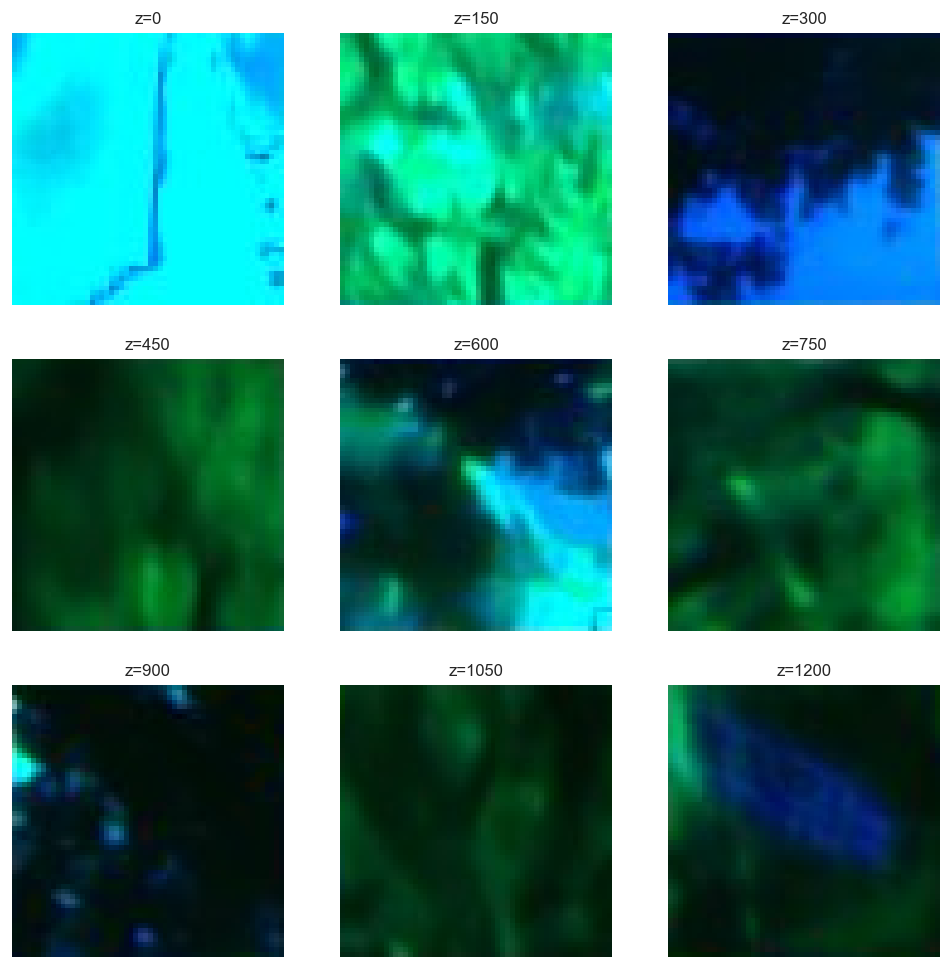

In [191]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axs.flat):
    frame = i * 150
    ax.set(xticks=[], yticks=[], title=f"z={frame}")
    ax.imshow(mc15[frame, :, :])
    ax.axis('off')

## Skeleton

In [7]:
skel_dir = 'Y:/data/Eyewire2/morphologies-ew2/swc-final/2007c8b3d5870b8742b720823ceab1a0/9e713c5362f2535135fe15417bfec1fa'
swc_files = [f for f in os.listdir(skel_dir) if f.endswith('.npz')]
print(len(swc_files))

1631


In [41]:
example_cell = {
    'nuc_id': "720575940567697697",
    'seg_id': "720575940559143627",
}

In [42]:
import skeliner as sk

skel = sk.io.load_npz(os.path.join(skel_dir, f"{example_cell['seg_id']}.npz"))

In [80]:
row = df_merged[df_merged.nuc_id == example_cell['nuc_id']].iloc[0]

# Plot

In [128]:
from eyewire2_functional_analysis.style import set_rc_params

set_rc_params(notebook_dpi=None)

In [13]:
from eyewire2_functional_analysis import plot

In [11]:
fig_dir = './figures/'
os.makedirs(fig_dir, exist_ok=True)

## Overview

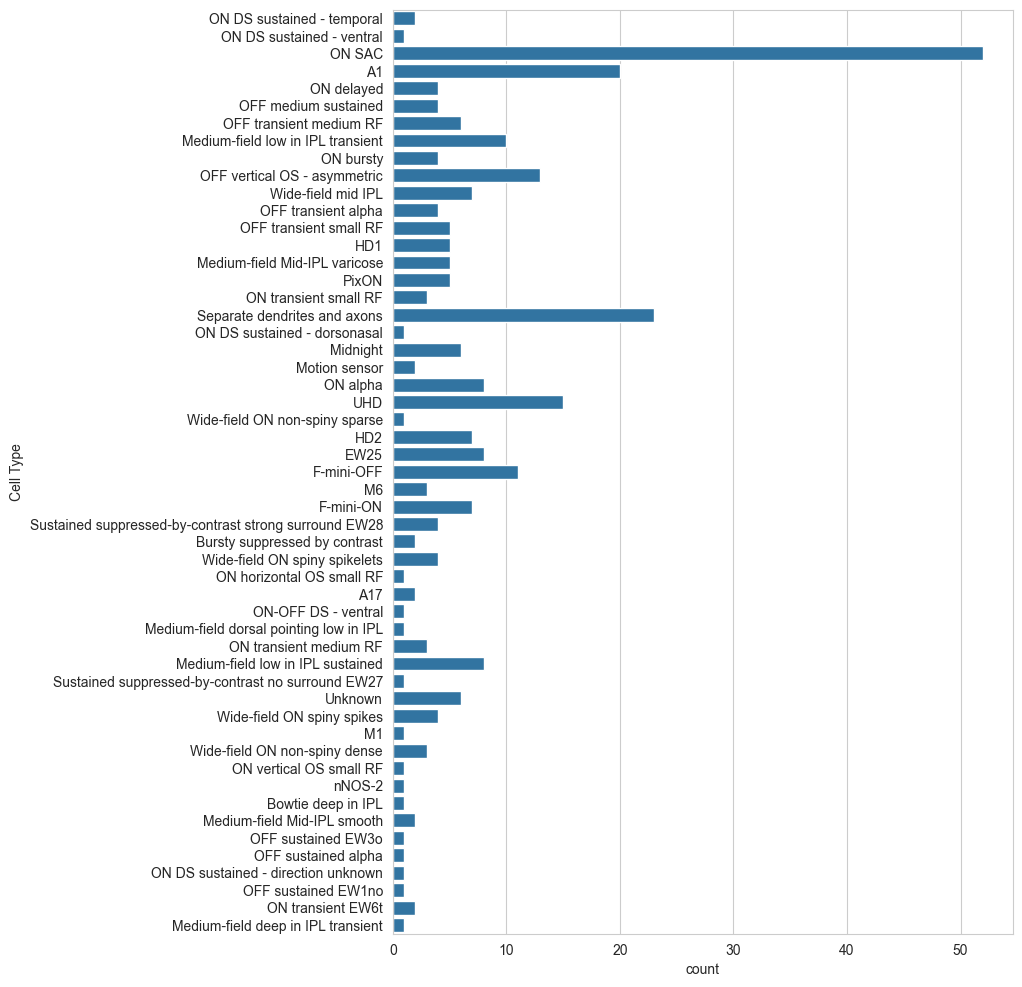

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

## Retina outline

## Example cell - Skeleton

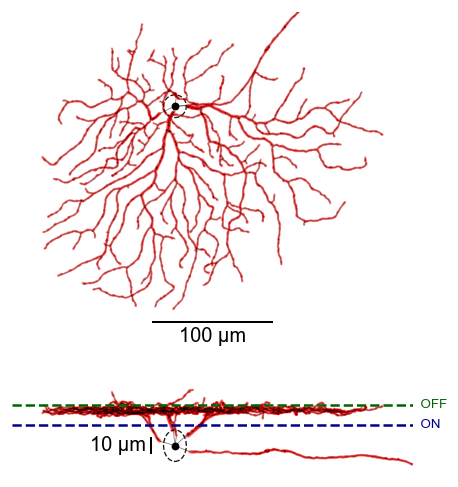

In [134]:
from eyewire2_functional_analysis.skeleton import rotate_skel

skel_rot = rotate_skel(skel, rotation_deg=150)

xmax, ymax, zmax = np.max(skel_rot.nodes[skel.ntype == 3], axis=0)
xmin, ymin, zmin = np.min(skel_rot.nodes[skel.ntype == 3], axis=0)

xlim = (xmin - 10, xmax + 30)
ylim = (ymin - 10, ymax + 10)
zlim = (zmin - 10, zmax + 5)

xlim = (xmin - 10, xmax + 10)
ylim = (ymin - 25, ymax + 25)
zlim = (zmin - 20, zmax + 5)

fig, axs = plt.subplots(2, 1, figsize=(4, 5), height_ratios=(5, 1))

ax = axs[0]
sk.plot.projection(skel_rot, ax=ax, xlim=ylim, ylim=xlim, plane='yx', draw_cylinders=False)
plot.plot_scale_bar(ax=ax, x0=np.mean(ylim), y0=xlim[0], size=100, text=True, unit='µm', tdist=4, fontsize=12)

ax = axs[1]
sk.plot.projection(skel_rot, ax=ax, xlim=ylim, ylim=zlim, plane='yz')
ax.set_aspect('auto', 'box')
ax.plot(ylim, [0, 0], c='darkblue', ls='--', lw=1.5)
ax.text(ylim[1], 0, '  ON', va='center', ha='left', color='darkblue', fontsize=8)
ax.plot(ylim, [12, 12], c='darkgreen', ls='--', lw=1.5)
ax.text(ylim[1], 12, '  OFF', va='center', ha='left', color='darkgreen', fontsize=8)
plot.plot_scale_bar(ax=ax, x0=skel_rot.soma.center[1] - 20, y0=skel_rot.soma.center[2],
                    size=10, text=True, unit='µm', tdist=-50, fontsize=12, orientation='v')

for ax in axs:
    ax.axis('off')

plt.savefig(os.path.join(fig_dir, 'fig4f.svg'))

## Example cell - Responses

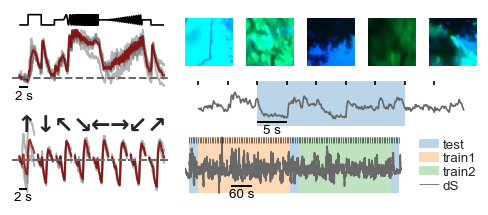

In [215]:
fig, axs = plt.subplot_mosaic(
    """
    AEFGHI
    ACCCCC
    .CCCCC
    BCCCCC
    BDDDDD
    """,
    figsize=(5, 2),
    width_ratios=(1, 0.3, 0.3, 0.3, 0.3, 0.3),
    height_ratios=(1, 0.2, 0.2, 0.2, 1),
)

ax = axs['A']
plot.plot_chirp(ax, row=row, stimulus_ms=chirp_stimulus)
ax.axis('off')
plot.plot_scale_bar(ax=ax, x0=1, y0=-0.2, size=2, text=True, unit='s', tdist=0.05, fontsize=8)

ax = axs['B']
plot.plot_bar(ax, row=row, annotate_symbols=True)
plot.plot_scale_bar(ax=ax, x0=1, y0=-0.7, size=2, text=True, unit='s', tdist=0.05, fontsize=8)
ax.axis('off')

ax = axs['D']
mc_trace = row.mc_trace
mc_time = np.arange(mc_trace.size) * row.mc_trace_dt + row.mc_trace_t0
mc_tt = row.mc_triggertimes
mc_tt = np.append(mc_tt, mc_tt[-1] + np.median(np.diff(mc_tt)))
mc_ylim = (mc_trace.min(), mc_trace.max())

ax.axis('off')
for test_i in [0, 59, 118]:
    ax.fill_between(x=[mc_tt[test_i], mc_tt[test_i + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C0', alpha=0.3, lw=0,
                    label='test' if test_i == 0 else '_')

ax.fill_between(x=[mc_tt[5], mc_tt[5 + 54]], y1=mc_ylim[0], y2=mc_ylim[1], color='C1', alpha=0.3, lw=0, label='train1')
ax.fill_between(x=[mc_tt[59 + 5], mc_tt[59 + 54 + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C2', alpha=0.3, lw=0,
                label='train2')

ax.plot(mc_time, mc_trace, c='dimgray', lw=1)
ax.vlines(mc_tt, ymin=mc_ylim[1] - np.diff(mc_ylim) * 0.1, ymax=mc_ylim[1], colors='k', linestyles='-', lw=0.3,
          label='dS')

ax.legend(bbox_to_anchor=(0.8, 0.5), loc='center left', borderaxespad=0., frameon=False, handlelength=1.5,)
plot.plot_scale_bar(ax=ax, x0=np.mean(mc_tt[:len(mc_tt) // 2]), y0=mc_ylim[0] + 3, size=60, text=True, unit='s',
                    tdist=1, fontsize=8)
ax.set_xlim(mc_time[0], mc_time[-1] + (mc_time[-1] - mc_time[0]) * 0.35)

ax = axs['C']
tlim_test2 = (mc_tt[59] - mc_tt[59 + 5])
ilim = (mc_time >= mc_tt[59] - 10) & (mc_time <= mc_tt[59 + 5] + 10)
ax.axis('off')
ax.plot(mc_time[ilim], mc_trace[ilim], c='dimgray', lw=1)
for test_i in [59]:
    ax.fill_between(x=[mc_tt[test_i], mc_tt[test_i + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C0', alpha=0.3, lw=0,
                    label='test' if test_i == 0 else '_')

ax.vlines(mc_tt[59 - 2:59 + 5 + 2], ymin=mc_ylim[1] - np.diff(mc_ylim) * 0.1, ymax=mc_ylim[1], colors='k',
          linestyles='-', lw=1)
plot.plot_scale_bar(ax=ax, x0=mc_tt[59] + 2.5, y0=mc_ylim[0] + 2, size=5, text=True, unit='s', tdist=1, fontsize=8)

for i in range(5):
    seq = 59 + i
    frame = seq * 30 * 5
    ax = axs[['E', 'F', 'G', 'H', 'I'][i]]
    ax.set(xticks=[], yticks=[])
    ax.imshow(mc15[frame, :, :])
    ax.axis('off')

plt.savefig(os.path.join(fig_dir, 'fig4g.svg'))